In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# 1. Data Import

# Verbatim file name for consistency

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# 2. Data Cleaning & Transformation

# Splitting Blood Pressure into Systolic and Diastolic integers

In [3]:
df['HRES'] = (df['Sleep Duration'] * df['Quality of Sleep']) / (df['Stress Level'] + 1)

# Custom Metric: Recovery Efficiency Score (HRES)

# High HRES = Effective recovery despite stress

In [15]:
df['HRES'] = (df['Sleep Duration'] * df['Quality of Sleep']) / (df['Stress Level'] + 1)

# 3. Statistical Analysis

# Testing Biological Inflation (Young vs Old sleep quality)

In [20]:



t_stat, p_val = stats.ttest_ind(young, old, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_val}")

if p_val < 0.05:
    print(f"Significant difference (p={p_val:.4f})")
else:
    print(f"No significant difference (p={p_val:.4f})")

T-statistic: -9.182645527100803
P-value: 1.334930449714904e-13
Significant difference (p=0.0000)


# Correlation: Activity vs Sleep Duration

In [21]:
steps_sleep_corr = df['Daily Steps'].corr(df['Sleep Duration'])

# BP Velocity: How fast BP increases with age

In [22]:
df['Systolic_BP'] = df['Blood Pressure'].apply(lambda x: int(str(x).split('/')[0]))
slope, intercept, r_value, p_val_bp, std_err = stats.linregress(df['Age'], df['Systolic_BP'])

print(f"Slope (Velocity): {slope:.4f}")


Slope (Velocity): 0.5413


# 4. Results Printing

In [23]:
print(f"--- RESEARCH METRICS ---")
print(f"Biological Inflation P-Value: {p_val:.2e}")
print(f"Activity/Sleep Correlation: {steps_sleep_corr:.4f}")
print(f"Annual BP Velocity (Slope): {slope:.4f}")

--- RESEARCH METRICS ---
Biological Inflation P-Value: 1.33e-13
Activity/Sleep Correlation: -0.0395
Annual BP Velocity (Slope): 0.5413


# 5. Dashboard Visualization

# Visual 1: Biological Inflation Trend

Text(0.5, 1.0, 'Biological Inflation: Age vs Sleep Quality')

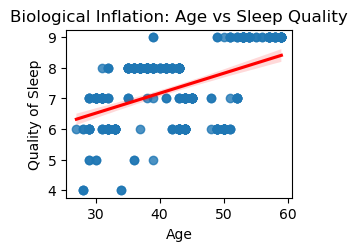

In [25]:
plt.subplot(2, 2, 1)
sns.regplot(data=df, x='Age', y='Quality of Sleep', line_kws={'color':'red'})
plt.title('Biological Inflation: Age vs Sleep Quality')

# Visual 2: Occupation Ranking by HRES

Text(0.5, 1.0, 'Recovery Efficiency Score HRES) Ranking')

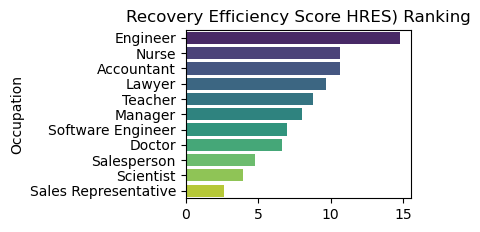

In [10]:
plt.subplot(2, 2, 2)
res_avg = df.groupby('Occupation')['HRES'].mean().sort_values(ascending=False)

# Warning hatane ke liye hue aur legend parameter add kiye hain
sns.barplot(
    x=res_avg.values, 
    y=res_avg.index, 
    palette='viridis', 
    hue=res_avg.index, 
    legend=False
)

plt.title('Recovery Efficiency Score HRES) Ranking')

# Visual 3: Stress vs Heart Rate Density

Text(0.5, 1.0, 'Executive Health Analysis: Stress vs Heart Rate')

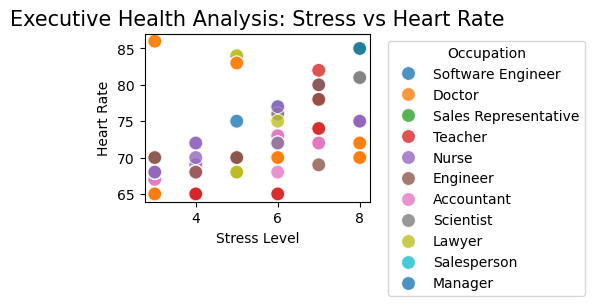

In [27]:
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='Stress Level', y='Heart Rate', hue='Occupation', s=100, alpha=0.8, palette='tab10')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Occupation')
plt.title('Executive Health Analysis: Stress vs Heart Rate', fontsize=15)

# Visual 4: Burnout Risk by Profession

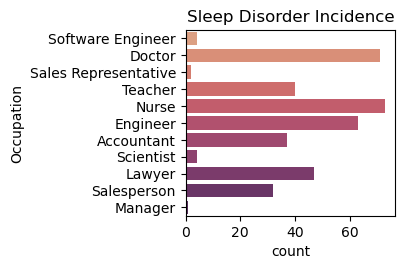

In [28]:
plt.subplot(2, 2, 4)
disorder_df = df[df['Sleep Disorder'] != 'None']

# Warning fix: y variable ko hi hue mein assign kiya aur legend band kar diya
sns.countplot(
    data=disorder_df, 
    y='Occupation', 
    palette='flare', 
    hue='Occupation', 
    legend=False
)

plt.title('Sleep Disorder Incidence')

plt.tight_layout()
plt.show()

In [29]:
df.to_csv("final_data.csv", index=False)

In [30]:
import os


print("Current Working Directory:", os.getcwd())


print("Files in the directory:", os.listdir())


Current Working Directory: C:\Users\ACER\sleep
Files in the directory: ['.ipynb_checkpoints', 'final_data.csv', 'HRES.ipynb', 'Sleep_Analysis.xlsx', 'Sleep_health_and_lifestyle_dataset.csv']


In [31]:
df.to_csv(r"C:\Users\ACER\Downloads\processed_sleep_data.csv", index=False)


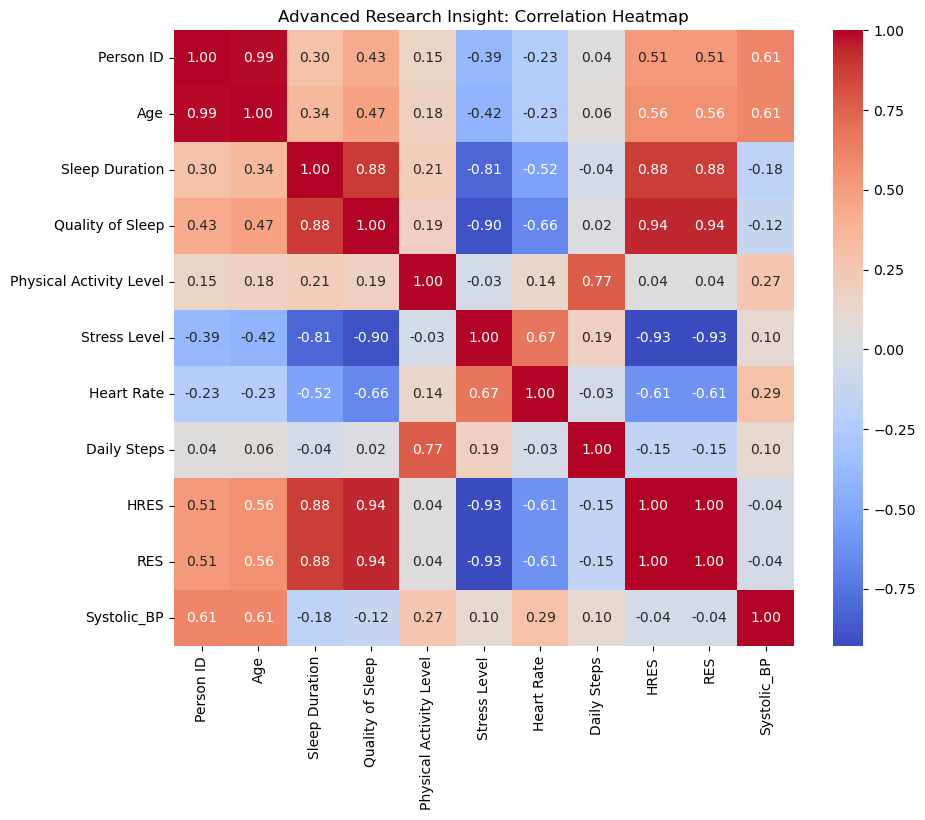

In [32]:

plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Advanced Research Insight: Correlation Heatmap')
plt.show()



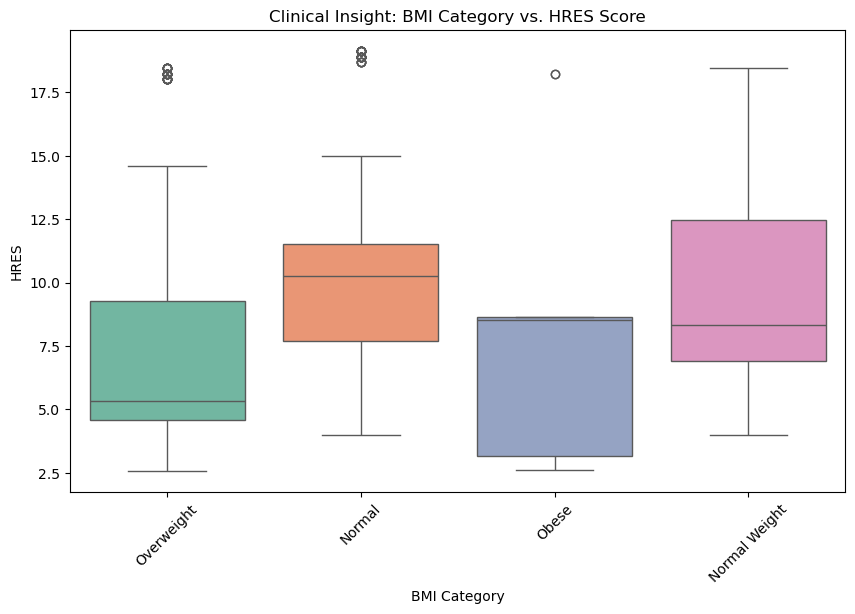

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='BMI Category', y='HRES', hue='BMI Category', palette='Set2', legend=False)

plt.title('Clinical Insight: BMI Category vs. HRES Score')
plt.xticks(rotation=45)
plt.show()
print("="*40)

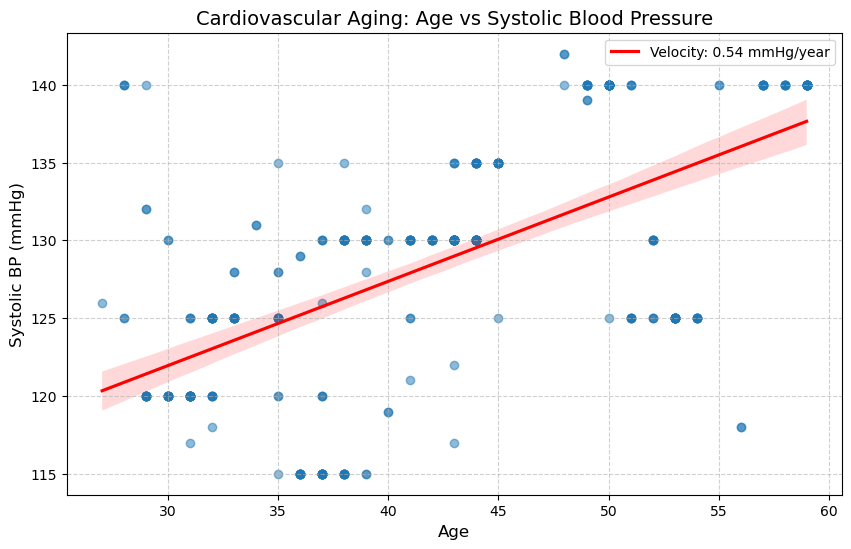

In [34]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Systolic_BP', 
            scatter_kws={'alpha':0.5}, 
            line_kws={'color':'red', 'label':'Velocity: 0.54 mmHg/year'})
plt.title('Cardiovascular Aging: Age vs Systolic Blood Pressure', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Systolic BP (mmHg)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

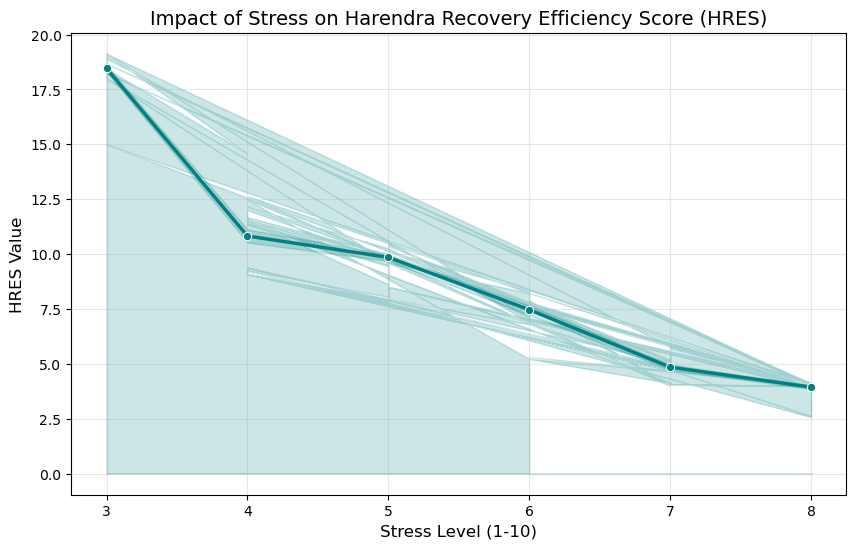

In [35]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Stress Level', y='HRES', marker='o', color='teal', linewidth=2.5)
plt.fill_between(df['Stress Level'], df['HRES'], alpha=0.2, color='teal')
plt.title('Impact of Stress on Harendra Recovery Efficiency Score (HRES)', fontsize=14)
plt.xlabel('Stress Level (1-10)', fontsize=12)
plt.ylabel('HRES Value', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

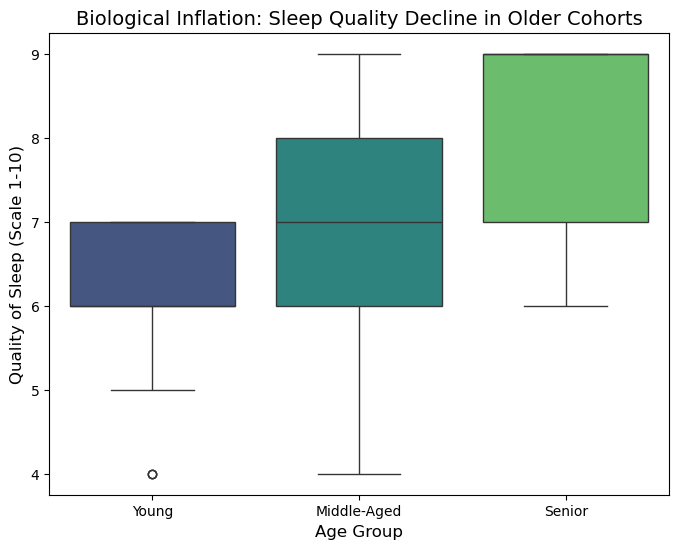

In [37]:

def categorize_age(age):
    if age <= 30:
        return 'Young'
    elif age >= 50:
        return 'Senior'
    else:
        return 'Middle-Aged'

df['Age_Group'] = df['Age'].apply(categorize_age)


plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Age_Group', y='Quality of Sleep', hue='Age_Group', palette='viridis', legend=False)

plt.title('Biological Inflation: Sleep Quality Decline in Older Cohorts', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Quality of Sleep (Scale 1-10)', fontsize=12)
plt.show()